In [1]:
import os
import torch
import torch.nn as nn
from torch.nn import functional as F
import chardet
import pickle
import collections
import re
import random
import matplotlib.pyplot as plt
import numpy as np
import math

HYPERPARAMETERS

In [2]:
batch_size = 8         
block_size = 256       
max_iters = 7000       
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200         
n_embd = 256
n_head = 4
n_kv_head = 2
n_layer = 4
dropout = 0.2
torch.manual_seed(1337)

DATA LOADING

In [3]:
file_path = "/kaggle/input/cleaned-data/cleaned_data.txt"

# Detect encoding
with open(file_path, "rb") as f:
    raw = f.read(10_000_000)  # read first 10 MB to detect encoding
    result = chardet.detect(raw)
print("Detected encoding:", result)

# Load full text
with open(file_path, "r", encoding=result["encoding"], errors="ignore") as f:
    text = f.read()

print("Total chars in dataset:", len(text))
char = sorted(list(set(text)))
vocab_size = len(char)
print(f"Unique chars: {vocab_size}")

Detected encoding: {'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}
Total chars in dataset: 15953988
Unique chars: 114


TOKENIZER

In [4]:
import os
import pickle

tokenizer_file = '/kaggle/input/bpe-tokenizer/bpe_tokenizer.pkl'

if os.path.exists(tokenizer_file):
    with open(tokenizer_file, 'rb') as f:
        tokenizer_data = pickle.load(f)
    stoi = tokenizer_data['stoi']
    itos = tokenizer_data['itos']
    vocab_size = tokenizer_data['vocab_size']
    print(f"Loaded tokenizer with {vocab_size} tokens")
else:
    raise FileNotFoundError(f"Tokenizer file '{tokenizer_file}' not found. "
                           "Please ensure the tokenizer file is available in Kaggle input.")

print(f"BPE vocab size: {vocab_size}")

def encode_text(text):
    """Encode text using the loaded BPE tokenizer."""
    tokens = []
    for word in text.split():
        w = '▁' + ' '.join(list(word)) + ' </w>'
        i = 0
        while i < len(w):
            for j in range(len(w), i, -1):
                piece = w[i:j]
                if piece in stoi:
                    tokens.append(stoi[piece])
                    i = j
                    break
            else:
                i += 1
    return tokens

def decode_tokens(token_ids):
    """Decode token IDs back to text using the loaded BPE tokenizer."""
    text = ''.join([itos[i] for i in token_ids])
    text = text.replace('▁', ' ').replace('</w>', '')
    return text

Loaded tokenizer with 2943 tokens
BPE vocab size: 2943


DATA SPLITTING

In [5]:
data = torch.tensor(encode_text(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
del text  

MODEL COMPONENTS

In [6]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),
            nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)

class GroupQueryAttention(nn.Module):
    def __init__(self, n_head, n_kv_head, head_size, n_embd):
        super().__init__()
        assert n_head % n_kv_head == 0
        self.n_head, self.n_kv_head, self.head_size = n_head, n_kv_head, head_size
        self.q_proj = nn.Linear(n_embd, n_head*head_size, bias=False)
        self.k_proj = nn.Linear(n_embd, n_kv_head*head_size, bias=False)
        self.v_proj = nn.Linear(n_embd, n_kv_head*head_size, bias=False)
        self.out_proj = nn.Linear(n_head*head_size, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer('mask', mask)

    def forward(self, x):
        B,T,C = x.shape
        q = self.q_proj(x).view(B,T,self.n_head,self.head_size).transpose(1,2)
        k = self.k_proj(x).view(B,T,self.n_kv_head,self.head_size).transpose(1,2)
        v = self.v_proj(x).view(B,T,self.n_kv_head,self.head_size).transpose(1,2)
        n_rep = self.n_head // self.n_kv_head
        k = k.repeat_interleave(n_rep, dim=1)
        v = v.repeat_interleave(n_rep, dim=1)
        attn = (q @ k.transpose(-2,-1)) * (self.head_size ** -0.5)
        attn = attn.masked_fill(self.mask[:T,:T]==0,float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = attn @ v
        out = out.transpose(1,2).contiguous().view(B,T,self.n_head*self.head_size)
        out = self.out_proj(out)
        out = self.dropout(out)
        return out

class Block(nn.Module):
    def __init__(self, n_embd, n_head, n_kv_head):
        super().__init__()
        self.sa = GroupQueryAttention(n_head, n_kv_head, n_embd//n_head, n_embd)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, n_kv_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None: nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


DATA BATCHING

In [7]:
def get_batch(split):
    data = train_data if split=='train' else val_data
    ix = torch.randint(0, len(data)-block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss_and_perplexity():
    model.eval()
    out_loss = {}
    out_perplexity = {}
    for split in ['train','val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X,Y = get_batch(split)
            _, loss = model(X,Y)
            losses[k] = loss.item()
        avg_loss = losses.mean().item()
        out_loss[split] = avg_loss
        out_perplexity[split] = math.exp(avg_loss)  # Perplexity = exp(loss)
    model.train()
    return out_loss, out_perplexity


TRAINING

Model parameters: 4.47M
Starting training...
Step 0: train loss 8.0096, val loss 8.0108
         train perplexity 3009.80, val perplexity 3013.23
Step 500: train loss 2.5227, val loss 2.5312
         train perplexity 12.46, val perplexity 12.57
Step 1000: train loss 2.2805, val loss 2.3033
         train perplexity 9.78, val perplexity 10.01
Step 1500: train loss 2.0525, val loss 2.0786
         train perplexity 7.79, val perplexity 7.99
Step 2000: train loss 1.9318, val loss 1.9603
         train perplexity 6.90, val perplexity 7.10
Step 2500: train loss 1.8707, val loss 1.8895
         train perplexity 6.49, val perplexity 6.62
Step 3000: train loss 1.8075, val loss 1.8391
         train perplexity 6.10, val perplexity 6.29
Step 3500: train loss 1.7606, val loss 1.7978
         train perplexity 5.82, val perplexity 6.04
Step 4000: train loss 1.7351, val loss 1.7782
         train perplexity 5.67, val perplexity 5.92
Step 4500: train loss 1.7164, val loss 1.7505
         train perplex

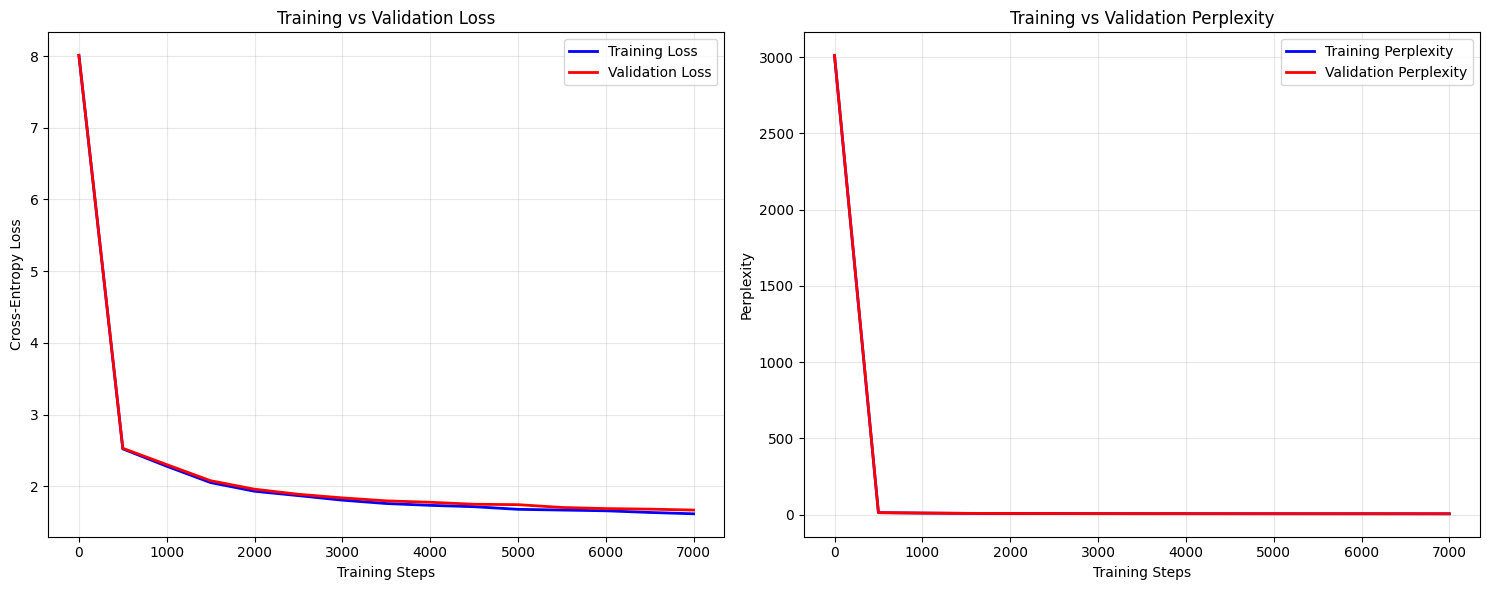

Plots saved to: training_metrics.png


In [8]:
model = BigramLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# Lists to store metrics for plotting
train_losses = []
val_losses = []
train_perplexities = []
val_perplexities = []
steps = []

print("Starting training...")
for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters-1:
        losses, perplexities = estimate_loss_and_perplexity()
        
        # Store metrics for plotting
        steps.append(iter)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        train_perplexities.append(perplexities['train'])
        val_perplexities.append(perplexities['val'])
        
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"         train perplexity {perplexities['train']:.2f}, val perplexity {perplexities['val']:.2f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb,yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print("\nGenerating plots...")

# Create a figure with 2 subplots
plt.figure(figsize=(15, 6))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(steps, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Training and Validation Perplexity
plt.subplot(1, 2, 2)
plt.plot(steps, train_perplexities, 'b-', label='Training Perplexity', linewidth=2)
plt.plot(steps, val_perplexities, 'r-', label='Validation Perplexity', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Perplexity')
plt.title('Training vs Validation Perplexity')
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plot_path = 'training_metrics.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to: {plot_path}")



EVALUATION

In [9]:
print("\nFinal Evaluation:")
final_losses, final_perplexities = estimate_loss_and_perplexity()
print(f"Final Training Loss: {final_losses['train']:.4f}")
print(f"Final Validation Loss: {final_losses['val']:.4f}")
print(f"Final Training Perplexity: {final_perplexities['train']:.2f}")
print(f"Final Validation Perplexity: {final_perplexities['val']:.2f}")

torch.save(model.state_dict(), 'gqa_model_final.pth')
print("✅ Model saved")

# Save metrics to file for later analysis
metrics_data = {
    'steps': steps,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_perplexities': train_perplexities,
    'val_perplexities': val_perplexities
}

metrics_path = 'training_metrics.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_data, f)
print(f"Metrics data saved to: {metrics_path}")

# Generate sample text
print("\n--- Generated Text ---")
context = torch.zeros((1,1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=300)
print(decode_tokens(generated[0].tolist()))


Final Evaluation:
Final Training Loss: 1.6289
Final Validation Loss: 1.6616
Final Training Perplexity: 5.10
Final Validation Perplexity: 5.27
✅ Model saved
Metrics data saved to: training_metrics.pkl

--- Generated Text ---
!वा, निर्देश में एं0 मार्लज़ इंडेक्टर लिखी उपना के तो-पहार स्तों के रिपि किया और कई 8,3007 में थी, जिसमें 15011 को तो ब्रिटेनियर पर लागू की छिपण करेखार्य के उपरबयो कर देश में लोकस्वेद से पहुंच गया था, रहै व थियों बिन गयी थी, जिनके और एक से 385005 से ऐसे बहुत पर प्रोटर पडे ता की कई आ होगे औरमिक सुरक्ष
